In [1]:
import pandas as pd
import numpy as np
import os

In [3]:
os.getcwd()

'C:\\Users\\Dell\\OneDrive - City Community Education Consultancy Pvt. Ltd\\Desktop\\data-aggrigation'

In [7]:
Base = "detection"
dir_list = os.listdir(Base)
print(dir_list)

['test', 'train']


In [10]:
import shutil
def move(source_folder, destination_folder):
    os.makedirs(destination_folder,exist_ok = True)
    for filename in os.listdir(source_folder):
        source_path = os.path.join(source_folder, filename)
        distination_path = os.path.join(destination_folder, filename)
        if os.path.isfile(source_path):
            shutil.move(source_path,  distination_path)
    print("all files are moved successfully!")

In [11]:
move('detection/test/images','appledataset/test')

all files are moved successfully!


In [12]:
path = "appledataset/test"
dir_list = os.listdir(path)
print(len(dir_list))

389


In [16]:
from PIL import Image
mask_files = sorted(__import__('glob').glob('detection/train/masks/*'))
print("sample masks:", mask_files[0])

mask = np.array(Image.open(mask_files[0]))
print("Mask shape:",mask.shape)
print("Unique Values:",np.unique(mask))

sample masks: detection/train/masks\20150919_174151_image1.png
Mask shape: (1280, 720)
Unique Values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95]


In [17]:
"""
mask_to_yolo.py — Convert MinneApple instance segmentation masks to YOLO bounding box labels.

Each mask is a single-channel image where each apple instance has a unique
non-zero integer pixel value (0 = background). For each unique value, we find
the tightest enclosing bounding box and write it as a normalized YOLO line.
"""

IMAGES_DIR = 'detection/train/images'
MASKS_DIR = 'detection/train/masks'
YOLO_LABELS_OUT = 'detection/train/yolo_labels'

os.makedirs(YOLO_LABELS_OUT, exist_ok=True)

mask_files = sorted(glob.glob(os.path.join(MASKS_DIR, '*')))
print(f"Found {len(mask_files)} mask files")

skipped = 0
converted = 0

for mask_path in mask_files:
    base_name = os.path.splitext(os.path.basename(mask_path))[0]

    # find matching image (extension may differ from mask)
    img_path = None
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']:
        candidate = os.path.join(IMAGES_DIR, base_name + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break
    if img_path is None:
        print(f"Warning: no matching image for {base_name}, skipping")
        skipped += 1
        continue

    with Image.open(img_path) as im:
        img_w, img_h = im.size

    mask = np.array(Image.open(mask_path))

    # handle masks that might have extra channels (RGB instead of single-channel)
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    instance_ids = np.unique(mask)
    instance_ids = instance_ids[instance_ids != 0]  # drop background (0)

    yolo_lines = []
    for inst_id in instance_ids:
        ys, xs = np.where(mask == inst_id)
        if len(xs) == 0:
            continue

        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()

        # skip degenerate/tiny boxes (likely mask noise, not a real apple)
        if (x_max - x_min) < 2 or (y_max - y_min) < 2:
            continue

        x_center = ((x_min + x_max) / 2) / img_w
        y_center = ((y_min + y_max) / 2) / img_h
        width = (x_max - x_min) / img_w
        height = (y_max - y_min) / img_h

        yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    label_path = os.path.join(YOLO_LABELS_OUT, base_name + '.txt')
    with open(label_path, 'w') as f:
        f.write('\n'.join(yolo_lines))

    converted += 1

print(f"\nDone. Converted: {converted}, Skipped (no image match): {skipped}")
print(f"YOLO labels written to: {YOLO_LABELS_OUT}")

Found 670 mask files

Done. Converted: 670, Skipped (no image match): 0
YOLO labels written to: detection/train/yolo_labels


Image: appledataset/train\20150919_174151_image101.png
Label: appledataset/train/yolo_labels\20150919_174151_image101.txt
Number of apples in this image: 102


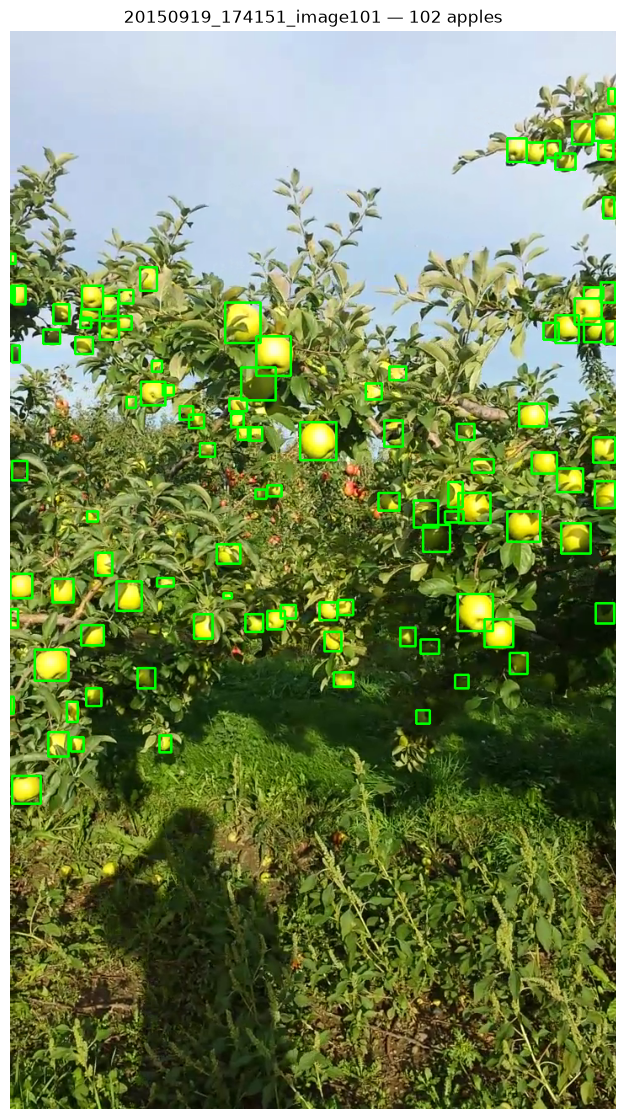

In [37]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

IMAGES_DIR = 'appledataset/train'
YOLO_LABELS_DIR = 'appledataset/train/yolo_labels'

# Grab the first image (sorted for consistency)
image_files = sorted(glob.glob(os.path.join(IMAGES_DIR, '*')))
first_image_path = image_files[1]
base_name = os.path.splitext(os.path.basename(first_image_path))[0]
label_path = os.path.join(YOLO_LABELS_DIR, base_name + '.txt')

print("Image:", first_image_path)
print("Label:", label_path)

img = cv2.imread(first_image_path)
h, w = img.shape[:2]

with open(label_path) as f:
    lines = f.readlines()

print(f"Number of apples in this image: {len(lines)}")

for line in lines:
    parts = line.strip().split()
    if len(parts) != 5:
        continue
    cls_id, xc, yc, bw, bh = map(float, parts)

    x1 = int((xc - bw / 2) * w)
    y1 = int((yc - bh / 2) * h)
    x2 = int((xc + bw / 2) * w)
    y2 = int((yc + bh / 2) * h)

    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(14, 14))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"{base_name} — {len(lines)} apples")
plt.show()

In [20]:
move('detection/train/images','appledataset/train')

all files are moved successfully!


In [21]:
move('detection/train/yolo_labels','appledataset/train/yolo_labels' )

all files are moved successfully!


In [31]:
path = "appledataset/train"
dir_list = os.listdir(path)
print(len(dir_list))

903
